
(getting_started)=
# 🚀 Getting Started


:::{note}
This example shows the interactive capabilities of Matplotlib backends, and this will not appear in the static documentation. Please run this code on your machine to see the interactivity.
:::

This tutorial guides users through analyzing, visualizing, and generating synthetic birdsongs using the `wavesongs` Python package. 

::::{admonition} Google Colab Execution
:class: dropdown

If you are using Google Colabinstall the pacakge via pypi with the following code:

:::{code} bash
! git clone https://github.com/wavesongs/wavesongs
! pip install wavesongs
# enable hird party widgets (ipympl)
from google.colab import output
output.enable_custom_widget_manager()
:::

In addition, you have to change the results and audio folder to:
:::{code} python
audios = "/content/wavesongs/assets/audio"
results = "/content/wavesongs/assets/audio/results"
:::

This is because in Google Colab all is downloaded at the `contents` folder. 

:::{caution}
If you encounter an error message, reset the kernel and run the above cell again. After that, everything should work successfully. Ensure that the audios and results variables are correctly set to the appropriate paths in your environment.
:::

::::


In [ ]:
# %matplotlib ipympl

# import matplotlib.pyplot as plt
# import numpy as np

# t = np.linspace(0, 2 * np.pi, 1024)
# data2d = np.sin(t)[:, np.newaxis] * np.cos(t)[np.newaxis, :]

# fig, ax = plt.subplots()
# im = ax.imshow(data2d)
# ax.set_title('Pan on the colorbar to shift the color mapping\n'
#              'Zoom on the colorbar to scale the color mapping')

# fig.colorbar(im, ax=ax, label='Interactive colorbar')

# plt.show()

In [ ]:
# !pip install plotly ipywidgets

In [1]:
from wavesongs.core import bird

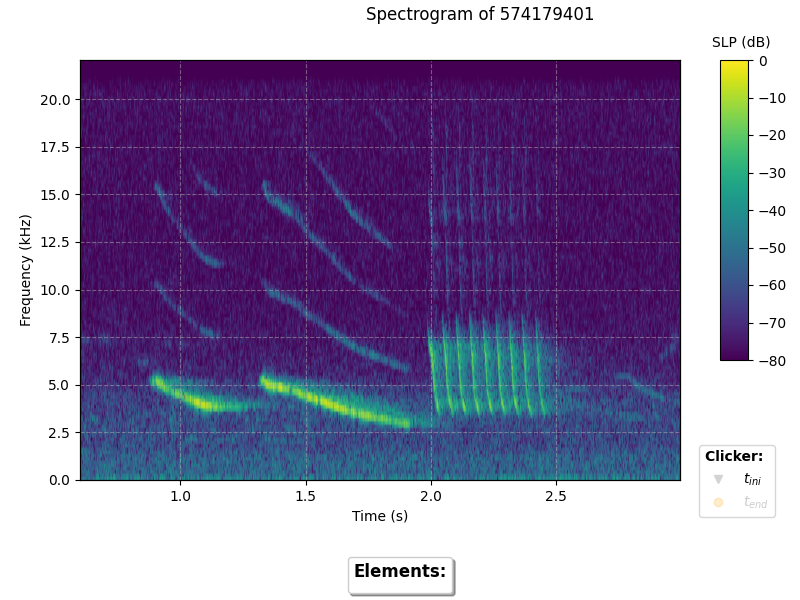

In [1]:
%matplotlib ipympl
from wavesongs.object import Syllable , Song
# from wavesongs.util import ProjDirs
from wavesongs.utils import plot


copeton = Song(file_id="XC144401" , tlim=(0, 10)) #, tlim=(1.0, 4.0)) # 574179401
# copeton = Syllable(file_id="XC842155", tlim=(23.3, 25.8))
copeton = Syllable(file_id="574179401", tlim=(0.6, 3))

copeton.acoustical_features(umbral_FF=1.4, n_fft=256, ff_method="yin")
# copeton_1.acoustical_features(umbral_FF=1., n_fft=512)

clicker = plot.set_plotter(library="matplotlib").spectrogram(copeton, type="2d", auxiliar="none",
                             mode="max", waveforme=False, ff=False, click="time")

In [23]:
copeton.play()

[(0.8840285129755607, 1.2614147724867728)]


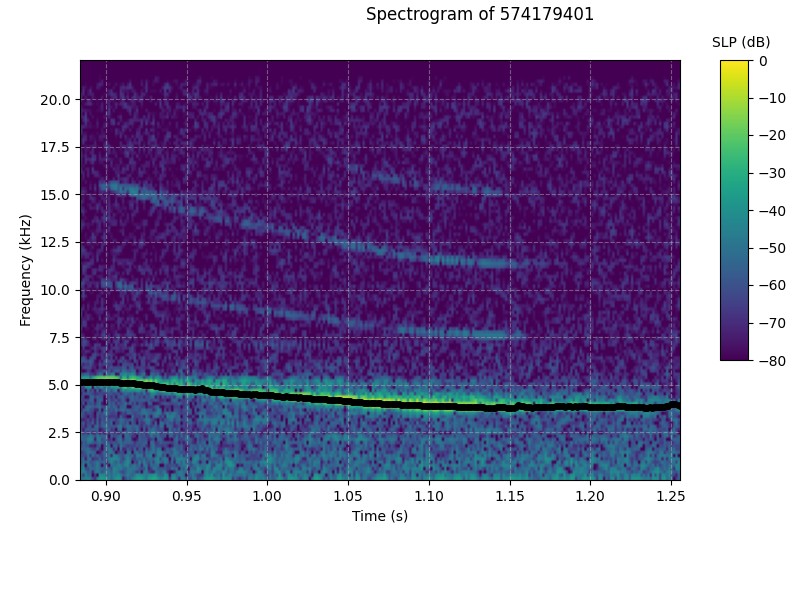

In [2]:
from wavesongs.utils.plot import get_roi


data = get_roi(clicker) # [(0.8951561965230537, 1.2734857868480727)] syllable 0
print(data)
tlim, flim = data[0] # index = 0: first pair

# # Add the initial time from the syllable
# t0 = tlim[0] + copeton_syllable.t0_bs
# tend = tlim[1] + copeton_syllable.t0_bs
# print(f"Region of Interest: (tini = {t0:.4f} s, tend = {tend:.4f} s)")

copeton0 = Syllable(file_id="574179401", tlim=data[0])

copeton0.acoustical_features(umbral_FF=1.4, n_fft=256, ff_method="yin")

_ = plot.set_plotter(library="matplotlib").spectrogram(copeton0, type="2d", auxiliar="none",
                             mode="max", waveforme=False, ff=True, click="none")

In [81]:
copeton0.play()

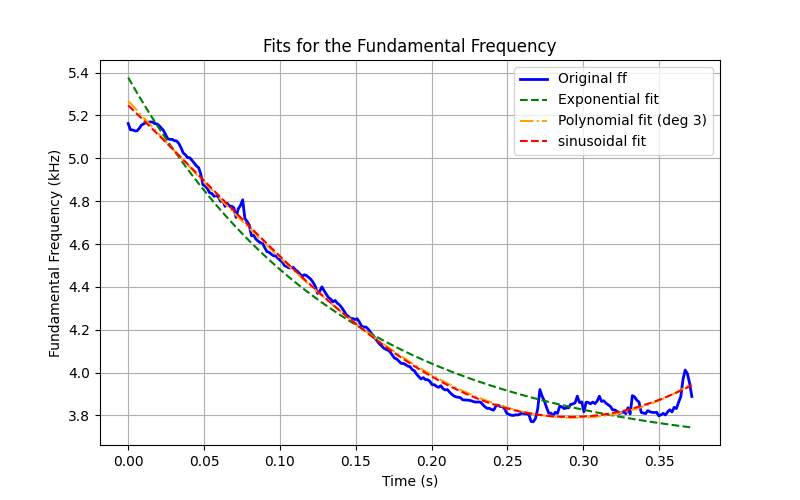

 Sinusoidal fit R^2:  0.9930, RMSE: 38.1032
 Exponential fit R^2: 0.9715, RMSE: 77.0750
 Polynomial fit R^2:  0.9920, RMSE: 40.7668
 Fit parameters/coefficients:
 Polynomial: [ 5268.003906   -7721.83671924  1327.48361014 26643.3916143 ]
 Sinusoidal: Av=4237.693, A=699.291, W=16.649, P=0.000
 Exponential: A=1757.502, B=-7.122, C=3619.320


In [69]:
# Exponential and Polynomial fitting for copeton0.ff
import numpy as np
from scipy.optimize import curve_fit
from numpy.polynomial import Polynomial
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.ticker as tkr

# Prepare data
t = copeton0.time
ff = copeton0.ff
time = copeton0.time_s
# Nonlinear fit of copeton0.ff using A+B*sin(C*t+D)
def sinusoidal(t, A, B, C, D):
    return A + B * np.sin(C * t + D)

# Initial guess for parameters: A, B, C, D
Av = np.mean(ff)
A = (np.max(ff) - np.min(ff)) / 2
W = 2 * np.pi / (time[-1] - t[0])
P = 0
p0 = [Av, A, W, P]

# Fit the data
params, cov = curve_fit(sinusoidal, t, ff, p0=p0, maxfev=10000)
A_fit, B_fit, C_fit, D_fit = params

# Calculate fitted values and metrics
ff_sin_fit = sinusoidal(t, *params)
r2 = r2_score(ff, ff_sin_fit)
rmse = np.sqrt(mean_squared_error(ff, ff_sin_fit))

# Exponential fit: ff = A * exp(B * t) + C
def exponential(t, A, B, C):
    return A * np.exp(B * t) + C

p0_exp = [np.max(ff), -1.0, np.min(ff)]
params_exp, _ = curve_fit(exponential, t, ff, p0=p0_exp, maxfev=10000)
ff_exp_fit = exponential(t, *params_exp)
r2_exp = r2_score(ff, ff_exp_fit)
rmse_exp = np.sqrt(mean_squared_error(ff, ff_exp_fit))

# Polynomial fit (degree 3)
poly_deg = 3
poly_fit = Polynomial.fit(t, ff, deg=poly_deg)
ff_poly_fit = poly_fit(t)
r2_poly = r2_score(ff, ff_poly_fit)
rmse_poly = np.sqrt(mean_squared_error(ff, ff_poly_fit))

# Plotting with custom y-axis formatter
def format_y_tick(value, tick_number):
    return f'{value * 1e-3:.1f}'  # Convert Hz to kHz

# Apply the custom formatter to the y-axis
yfmt = tkr.FuncFormatter(format_y_tick)

# Plot all fits
fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(t, ff, label='Original ff', color='blue', lw=2)
ax.plot(t, ff_exp_fit, label='Exponential fit', color='green', linestyle='--')
ax.plot(t, ff_poly_fit, label=f'Polynomial fit (deg {poly_deg})', color='orange', linestyle='-.')
ax.plot(t, ff_sin_fit, label='sinusoidal fit', color='red', linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Fundamental Frequency (kHz)')
ax.set_title('Fits for the Fundamental Frequency')
ax.legend()
ax.grid(True)
ax.yaxis.set_major_formatter(yfmt)
plt.show()

# Print results 
print(f' Sinusoidal fit R^2:  {r2:.4f}, RMSE: {rmse:.4f}\n',
      f'Exponential fit R^2: {r2_exp:.4f}, RMSE: {rmse_exp:.4f}\n',
      f'Polynomial fit R^2:  {r2_poly:.4f}, RMSE: {rmse_poly:.4f}\n',
      "Fit parameters/coefficients:\n",
      f'Polynomial: {poly_fit.convert().coef}\n',
      f'Sinusoidal: Av={Av:.3f}, A={A:.3f}, W={W:.3f}, P={P:.3f}\n',
      f'Exponential: A={params_exp[0]:.3f}, B={params_exp[1]:.3f}, C={params_exp[2]:.3f}')

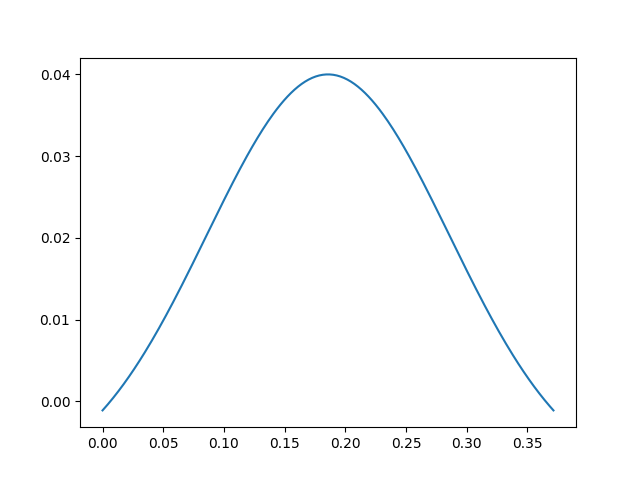

array([3.88885935e+03, 1.09563751e+03, 6.53752581e+00, 2.80885117e+00])

In [100]:
def gaussian(
            t: np.ndarray,
            a0: float,
            t0: float,
            a1: float = 0,
            sigma: float = 1,
            n: int = 1
        ) -> np.ndarray:
        return np.array(a0 * np.exp(-((t - t0)**(2*n) / (2*sigma**(2*n)))) + a1)

plt.figure()
plt.plot(t, gaussian(t, 0.05, t[-1]/2, sigma=0.1, a1=-0.01))
plt.show()

sinusoidal(time0, *params).shape,  synthetic.time_s.shape, copeton0.time_s.shape, t_ones.shape
params

Elapsed time: 18.014 seconds


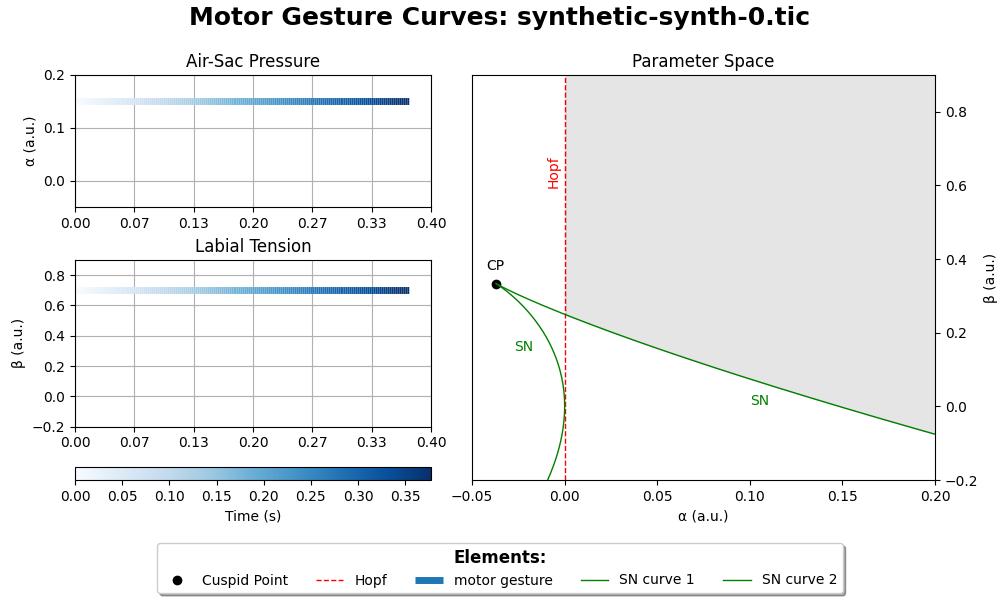

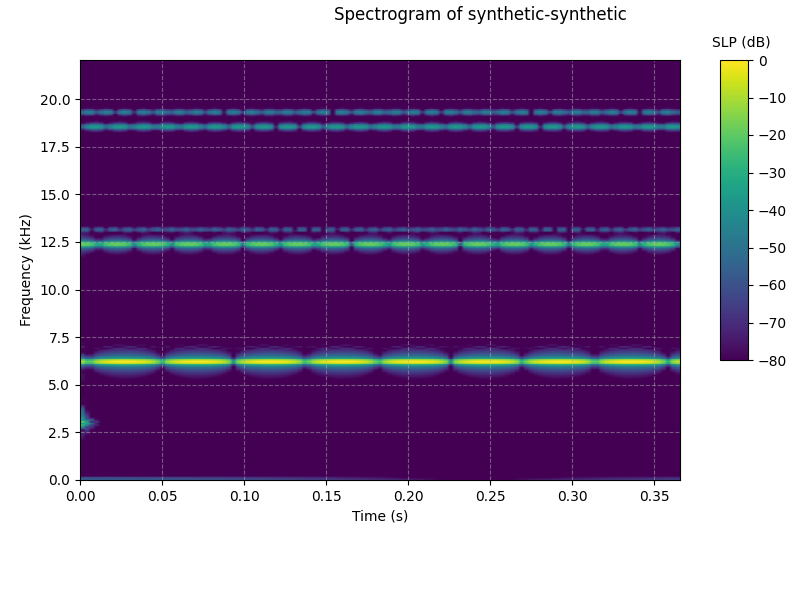

In [115]:
from wavesongs.utils import plot
from wavesongs.object import Synthetic
from wavesongs.data.manager import ProjDirs
import numpy as np

proj_dirs = ProjDirs(audios="./assets/audios", results="./assets/results_pure_synthetic")
ploter = plot.set_plotter(library="matplotlib")

sr = 44100
time0 = copeton0.time_s

synthetic = Synthetic(duration=time0[-1], proj_dirs=proj_dirs, sr=sr)
synthetic.initialize()

synthetic.acoustical_features(umbral_FF=1.4, n_fft=512, ff_method="yin")
# _ = ploter.spectrogram(synthetic)#, ylim=(0, 0.5)) # simple line in lwo frequency

from wavesongs.core.bird import Model
import time

model = Model(ovsr=10)


start_time = time.perf_counter()
ploter._COLORS["motor_gesture"] = "Blues"
# t_ones = np.linspace(0, time0[-1], sr)
# curves = [0.01*t+0.04, exponential(t, 1, 0.2, 0, 1)]
# params = np.array([4.88885935e+03, 1.09563751e+03, 6.53752581, 2.80885117])
params = np.array([5.88885935e+03, 3.09563751e+03, 6.53752581, 2.80885117])
curves = [
    #0.01*t+0.04,
    # gaussian(time0, 0.05, time0[-1]/2, sigma=0.1, a1=-0.01),
    # sinusoidal(time0, *params) * 1e-4
    0.15*np.ones_like(time0), 0.7*np.ones_like(time0)
]

synthetic.z = {}
synthetized = model.motor_gesture(synthetic, curves)

end_time = time.perf_counter()

elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time:.3f} seconds")

# Plot motor gesture
_ = ploter.alpha_beta(synthetized, save=False)

# Plot waveform generated
synthetized.acoustical_features(umbral_FF=1.4, n_fft=512, ff_method="yin")
_ = ploter.spectrogram(synthetized, save=False)
synthetized.play()

In [ ]:
import numpy as np
from scipy.ndimage import label, generate_binary_structure, binary_dilation
from scipy.ndimage import binary_closing, binary_opening
from matplotlib.colors import BoundaryNorm
from matplotlib import cm

self = copeton
def region_growing(image: np.ndarray) -> np.ndarray: # seeds: np.ndarray
    """
    Performs region growing on a grayscale image using 8-connectivity.

    Parameters:
    - image: 2D numpy array (grayscale image).
    - seeds: 2D numpy array (same shape as image), 1s at seed points, 0s elsewhere.
    - predicate: function f(x, y, value) -> bool, returns True if pixel (x,y) satisfies condition.

    Returns:
    - labeled_image: 2D numpy array with labeled regions.
    """
    # assert image.shape == seeds.shape, "Image and seed array must have the same shape"
    image = self.Sxx_dB.copy()  # Use the dB-scaled spectrogram
    Sxx_dB_grayscale = self.Sxx_dB - self.Sxx_dB.min()
    Sxx_dB_grayscale = Sxx_dB_grayscale / Sxx_dB_grayscale.max()  # Normalize to [0, 1]

    struct = generate_binary_structure(2, 2)  # 8-connectivity

    # Fundamental frequency mask
    # if region_growing_params["ff"] == "yin":
    self.ff_mask = np.zeros_like(self.Sxx, dtype=bool)
    for t_idx, freq in enumerate(self.ff):
        f_idx = np.argmin(np.abs(self.freq - freq))
        self.ff_mask[f_idx, t_idx] = True
    seeds = self.ff_mask.astype(int)

    # Step 1: Reduce each connected component in S to one pixel
    labeled_seeds, num_seeds = label(seeds, structure=struct)
    reduced_seeds = np.zeros_like(seeds, dtype=np.uint8)
    seed_coords = []
    for i in range(1, num_seeds + 1):
        coords = np.argwhere(labeled_seeds == i)
        if coords.size > 0:
            reduced_seeds[tuple(coords[0])] = 1
            seed_coords.append(tuple(coords[0]))

    # Step 2: Form image fQ using predicate and distance restriction
    # mean_ff_dB = np.mean(image[seeds])
    percentile_80 = np.percentile(image[seeds.astype(bool)], 80)

    seed_coords = np.array(seed_coords)
    print("Seed coordinates: ", np.array(seed_coords).shape)
    fQ = np.zeros_like(image, dtype=np.uint8)
    for x in range(image.shape[0]):
        for y in range(image.shape[1]):
            # Check if (x, y) is within 20 pixels of any seed
            Sxx_dB_xy = image[x, y]
            if Sxx_dB_xy > percentile_80 \
              and np.min((x - seed_coords[:, 0]) ** 2) <= 10: # (np.min(np.sqrt((x - seed_coords[:, 0]) ** 2 + (y - seed_coords[:, 1]) ** 2)) <= 20):
                fQ[x, y] = 1

    # Step 3: Grow region by connecting seed points with 8-connected neighbors in fQ
    prev = np.zeros_like(reduced_seeds)
    current = reduced_seeds.copy()
    while not np.array_equal(current, prev):
        prev = current.copy()
        dilated = binary_dilation(current, structure=struct)
        current = np.logical_and(dilated, fQ).astype(np.uint8)

    # Step 4: Label the connected components in the grown region
    labeled_image, _ = label(current, structure=struct)

    return labeled_image

# self = copeton
# ff_mask_dB = self.Sxx_dB * self.ff_mask
import matplotlib.pyplot as plt

# Plot histogram of ff_mask_dB
# plt.figure(figsize=(8, 5))
# plt.hist(ff_mask_dB.flat, bins=30)#, color='orange', edgecolor='black')
# plt.title("Histogram of ff_mask_dB values")
# plt.xlabel("ff_mask_dB")
# plt.ylabel("Count")
# plt.show()

# Plot Sxx_dB with mask overlay
# Apply morphological closing to self.ff_mask
# closing = 1
# closed_ff_mask = self.ff_mask # binary_opening(self.ff_mask, structure=np.ones((closing, closing)))

# Sxx_dB_grayscale = self.Sxx_dB - self.Sxx_dB.min()
# Sxx_dB_grayscale = Sxx_dB_grayscale / Sxx_dB_grayscale.max()  # Normalize to [0, 1]

# mean_dB = ff_mask_dB.max() - ff_mask_dB.min()
# region_mask =  copeton.segmentation(mode="region_growing")#
region_mask = region_growing(copeton.Sxx)#,
            #    lambda x, y, value: value > 0.5)
# Show the closed mask overlay
plt.figure(figsize=(10, 5))
# plt.imshow(region_mask, aspect='auto', origin='lower', cmap='nipy_spectral')
# Get the number of unique region labels (excluding 0 for background)
# Use a more diverse colormap, e.g., 'tab20'

labels = np.unique(region_mask)
# labels = labels[labels != 0]
# boundaries = np.arange(region_mask.min(), region_mask.max() + 2) - 0.5
# norm = BoundaryNorm(boundaries, ncolors=len(boundaries)-1)

closing = 1

region_mask_post = binary_closing(region_mask, structure=np.ones((closing, closing)))
region_mask_post, _ = label(region_mask_post, structure=generate_binary_structure(2, 2))

labels_post = np.unique(region_mask_post)
labels_post = labels_post[labels_post != 0]


# labels = labels_post
# region_mask = labels
# labels = np.unique(region_mask)

diverse_cmap = plt.get_cmap('tab20', len(labels))
plt.imshow(region_mask_post, aspect='auto', origin='lower', cmap=diverse_cmap)
cbar = plt.colorbar(ticks=np.arange(region_mask.min(), region_mask.max() + 1), label="Region Label")
cbar.ax.set_yticklabels(np.arange(region_mask.min(), region_mask.max() + 1))

# plt.imshow(region_mask, aspect='auto', origin='lower', cmap='nipy_sregion_maskpectral', norm=norm)
plt.title("Region Growing Result (region_mask)")
plt.xlabel("Time bins")
plt.ylabel("Frequency bins")
# plt.colorbar(label="Region Label")
plt.show()


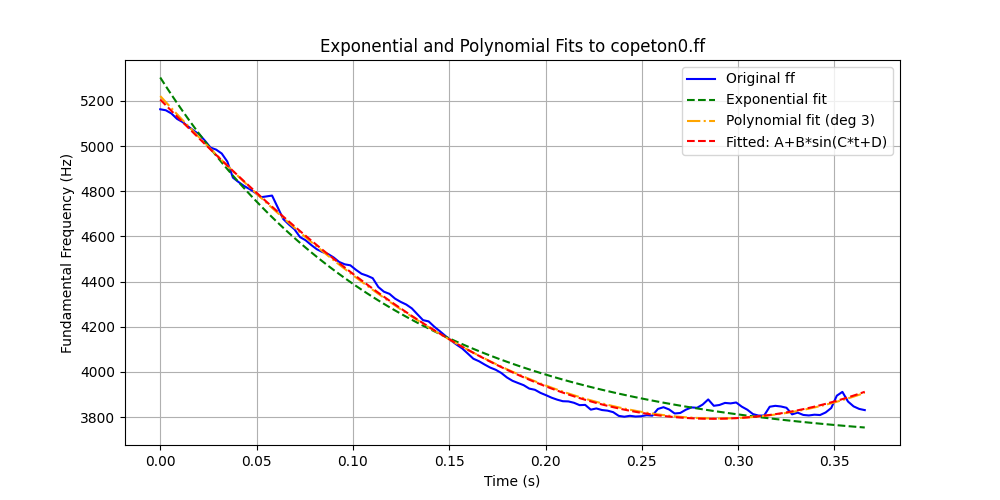

Fit parameters: A=6061.756, B=2269.303, C=4.129, D=3.528
Fit R^2: 0.9945, RMSE: 31.8770
Exponential fit parameters: A=1630.491, B=-8.213, C=3673.042
Exponential fit R^2: 0.9792, RMSE: 61.7269
Polynomial fit coefficients: [ 5221.40338493 -9323.29046884 13294.32548516  6491.89969065]
Polynomial fit R^2: 0.9941, RMSE: 32.9417


In [ ]:
mean_dB

In [ ]:
from librosa import stft
from skimage import exposure

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import binary_opening

plt.figure(figsize=(8, 5))
plt.hist(copeton.Sxx_dB.flatten(), bins=10, color='skyblue', edgecolor='black')
plt.title("Histogram of Sxx_dB values")
plt.xlabel("Sxx_dB")
plt.ylabel("Count")
plt.show()

# Apply histogram equalization to Sxx_dB
# Sxx_dB_eq = exposure.equalize_hist(copeton.Sxx_dB)

# plt.figure(figsize=(8, 5))
# plt.imshow(Sxx_dB_eq, aspect='auto', origin='lower', cmap='viridis')
# plt.title("Histogram Equalized Sxx_dB")
# plt.xlabel("Time bins")
# plt.ylabel("Frequency bins")
# plt.colorbar(label="Normalized Intensity")
# plt.show()

# Compute histogram and get bin edges
hist, bin_edges = np.histogram(copeton.Sxx_dB.flatten(), bins=10)

# Find indices of the three bins with the lowest counts
lowest_bins_idx = np.argsort(hist)[:7]

# Get the value ranges for these bins
mask = np.zeros_like(copeton.Sxx_dB, dtype=bool)
for idx in lowest_bins_idx:
  bin_min = bin_edges[idx]
  bin_max = bin_edges[idx + 1]
  mask |= (copeton.Sxx_dB >= bin_min) & (copeton.Sxx_dB < bin_max)

# Filtered Sxx_dB: keep only values in the selected bins, set others to np.nan
Sxx_dB_filtered = np.where(mask, copeton.Sxx_dB, np.nan)
# Create a binary mask where Sxx_dB_filtered is not nan
binary_mask = ~np.isnan(Sxx_dB_filtered)

# Apply closing filter to the binary mask
closed_mask = binary_opening(binary_mask, structure=np.ones((3, 3)))

# Apply the closed mask to Sxx_dB_filtered (keep values where closed_mask is True)
Sxx_dB_filtered = np.where(closed_mask, Sxx_dB_filtered, np.nan)
# Show the resulting spectrogram
plt.figure(figsize=(10, 5))
plt.imshow(Sxx_dB_filtered, aspect='auto', origin='lower', cmap='viridis')
plt.title("Spectrogram: Only Three Lowest Histogram Bars")
plt.xlabel("Time bins")
plt.ylabel("Frequency bins")
plt.colorbar(label="Sxx_dB (filtered)")
plt.show()


In [ ]:
copeton_1.play()
# copeton_1_synth = Syllable(file_id="123456789", duration=5)
# copeton_1_synth.acoustical_features(umbral_FF=1., n_fft=256)

# # plot.spectrogram_waveform(copeton_1, save=False, ff_on=True)

In [ ]:
copeton_1.freq.shape, copeton_1.time.shape, copeton_1.Sxx.shape
copeton_1.time.shape

In [ ]:
from wavesongs.plot import Plotly, Matplotlib
from wavesongs.objects import Syllable, Song
from wavesongs import plot

copeton_1 = Syllable(file_id="XC542500")#, tlim=(0.6, 3))#, tlim=(1.32, 1.91)) # (0.6, 3)
copeton_1.acoustical_features(umbral_FF=1.4, n_fft=512)


plotter_plty = Plotly(height=600, width=800)
plotter_plty.spectrogram(obj=copeton_1, type="2d", auxiliar="both", mode="max",
                         waveforme=True, grid=True, ff=True)

In [ ]:
from wavesongs.plot import Plotly, Matplotlib

ploter_mtpl = Matplotlib()

clicker = ploter_mtpl.spectrogram(copeton, type="2d", auxiliar="both", mode="max",
                                  waveforme=True, grid=True, ff=True, click="none")

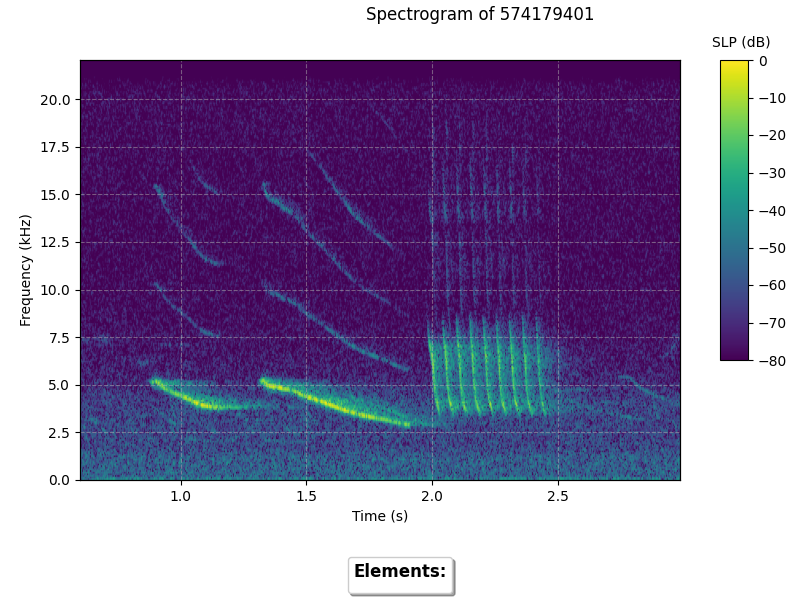

In [14]:
%matplotlib ipympl
copeton = Song(file_id="574179401", tlim=(0.6, 3))
copeton.acoustical_features(umbral_FF=1.4, n_fft=512)

from wavesongs.utils import plot
plotter_mtpl = plot.set_plotter("matplotlib")
clicker = plotter_mtpl.spectrogram(copeton, type="2d", auxiliar="none", mode="max",
                                   waveforme=False, grid=True, ff=False, click="time")

Number of points selected are not even. Remember you have               to select the same number of initial times as end times


[]

In [ ]:
%matplotlib ipympl
from wavesongs.object import Syllable , Song
from wavesongs.utils import plot

copeton = Syllable(file_id="574179401", tlim=(0.6, 3))

copeton.acoustical_features(umbral_FF=1.4, n_fft=512, ff_method="yin")

copeton.segmentation(
    mode = "signal_pro",
    threshold_1 = 0.2, threshold_2 = 1, min_duration = 0.01,
    img_pro_params = {
        "scalar": 3, # for the filter
        # "threshold": 1e-6, # PSD units
        # "pref": 34, # dB units
        "percentile": 80,
        "no_harmonics": 6,
        "min_area": 20, # pixels
        "min_duration": 9, # pixels
        "window_params": {"W": 64, "h":100},
        "stride": 2,
        "margin_pixels": 3,
        "times": 2, # for the model noisy
        "ff_computing": "yin",  # "yin", "pyin", "img_pro"
        "closing": 3,
    },
    region_growing_params = {
        "threshold": 100,
        "ff": "yin",
    },
    verbose = True,
)

_ = plotter_mtpl.segmentation(
    copeton,
    harmonics=False,
    fundamental=False,
    alpha=0.9,
    grid=False,
    colorbar=True,
    filters=True,
    figsize=(9, 7),
    label="syllables"
)
# # copeton.segments_time, #, copeton.segments_Sxx
# there is an error with the segmentation in the frequency axis

In [9]:
roi = copeton.regions[1][0]
tlim_roi = (roi["t_ini"]+0.01, roi["t_end"])


copeton_syllable_1 = Syllable(file_id="574179401", tlim=tlim_roi)

copeton_syllable_1.acoustical_features(umbral_FF=1.04, n_fft=512, ff_method="yin")

_ = plotter_mtpl.spectrogram(
  copeton_syllable_1, type="2d", auxiliar="both", mode="max",
  waveforme=True, ff=True, click="none",
)

AttributeError: 'Song' object has no attribute 'regions'

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.imshow(copeton.sorted_labels, aspect='auto', origin='lower', cmap='gray')
plt.title("Harmonic Mask")
plt.xlabel("Time bins")
plt.ylabel("Frequency bins")
plt.colorbar(label="Mask Value")
plt.show()

copeton.ff_sp.max(), copeton.ff_sp.min()


In [ ]:
%matplotlib ipympl
# from wavesongs.objects import Song
from wavesongs.util import plot
# copeton = Song(file_id="574179401",  tlim=(0.6, 3)) # tlim=(0.8, 1.3))#
# copeton = Syllable(file_id="XC388622", tlim=(5.6, 6.1))
# # copeton = Syllable(file_id="XC842155", tlim=(23.3, 25.8))
copeton.acoustical_features(umbral_FF=1.4, n_fft=512)

copeton.segmentation(
    mode= "signal_pro", #"region_growing",#
    threshold_1=0.15, threshold_2=0.8, min_duration= 0.01,
    img_pro_params={
        "scalar": 3,
        "threshold": 1e-6,
        # "pref": 34,  # dB
        "percentile": 80,
        "sigma": 1.0,
        "window_params": {"W": 64, "h": 100},
        "min_area": 20, # pixels
        "min_duration": 9, # pixels
        
        "no_harmonics": 6,
        "margin_pixels": 3,
        "times": 3,
        "ff_computing": "img_pro",  # "yin", "pyin", "img_pro"

        "closing": 3,
        "stride": 2, 
        
    },
)
# copeton.segments, copeton.segments_time
# Plotly().spectrogram(copeton, type="2d", auxiliar="none", mode="max", waveforme=True)

_ = Plotter("matplotlib").segmentation(
    copeton,
    harmonics=False,
    fundamental=False,
    alpha=0.9,
    grid=False,
    colorbar=True,
    filters=True,
    figsize=(9, 7),
    label="segments"
)
# copeton.segments_time, #, copeton.segments_Sxx

In [ ]:
import numpy as np

# copeton.regions[5]
# copeton.ff_regions[7]

# Reorder copeton.regions by 't_ini' in ascending order and update keys
ordered_regions = sorted(copeton.regions.items(), key=lambda x: x[1]['t_ini'])
copeton.regions = {i: v for i, (_, v) in enumerate(ordered_regions)}

ordered_ff_regions = sorted(copeton.ff_regions.items(), key=lambda x: x[1]['t_ini'])
copeton.ff_regions = {i: v for i, (_, v) in enumerate(ordered_ff_regions)}

for k in copeton.ff_regions.keys():
  # copeton.ff_regions[k]["label"] = k + 1
  copeton.ff_regions[k]["syllable_label"] = k + 1

import matplotlib.pyplot as plt

durations = [region["duration"] for region in copeton.ff_regions.values()]
bandwidths = [region["bw"] for region in copeton.ff_regions.values()]
areas = [region["area"] for region in copeton.ff_regions.values()]

# Clasyfing trill and template
percentage = 0.8
areas_arr = np.array(areas)
sorted_areas = np.sort(areas_arr)
n = int(np.ceil(percentage * len(sorted_areas)))
area_range = (sorted_areas[0], sorted_areas[n - 1])
print(f"{percentage * 100}% of the samples have area between {area_range[0]} and {area_range[1]}")
max_area_trill = area_range[1]


trill_syllables = {k: v for k, v in copeton.ff_regions.items() if v["area"] <= max_area_trill}
theme_syllables = {k: v for k, v in copeton.ff_regions.items() if v["area"] > max_area_trill}

theme = {
  "syllables": theme_syllables,
  "t_ini": min([v["t_ini"] for v in theme_syllables.values()]),
  "t_end": max([v["t_end"] for v in theme_syllables.values()]),
  "f_ini": min([v["f_ini"] for v in theme_syllables.values()]),
  "f_end": max([v["f_end"] for v in theme_syllables.values()])

} 
theme["bw"] = theme["f_end"] - theme["f_ini"]
theme["duration"] = theme["t_end"] - theme["t_ini"]

trill = {
  "syllables": trill_syllables,
  "t_ini": min([v["t_ini"] for v in trill_syllables.values()]),
  "t_end": max([v["t_end"] for v in trill_syllables.values()]),
  "f_ini": min([v["f_ini"] for v in trill_syllables.values()]),
  "f_end": max([v["f_end"] for v in trill_syllables.values()])

}

trill["bw"] = trill["f_end"] - trill["f_ini"]
trill["duration"] = trill["t_end"] - trill["t_ini"]


print("Theme time range:", theme["t_ini"], theme["t_end"],
      " - Trill time range:", trill["t_ini"], trill["t_end"],)

fig, axs = plt.subplots(1, 3, figsize=(9, 4))
axs[0].hist(durations, bins=10, color='skyblue', edgecolor='black')
axs[0].set_title("Duration")
axs[0].set_xlabel("Duration (s)")
axs[0].set_ylabel("Count")

axs[1].hist(bandwidths, bins=10, color='salmon', edgecolor='black')
axs[1].set_title("Bandwidth")
axs[1].set_xlabel("Bandwidth (Hz)")
axs[1].set_ylabel("Count")

axs[2].hist(areas, bins=10, color='lightgreen', edgecolor='black')
axs[2].set_title("Area")
axs[2].set_xlabel("Area (samples)")
axs[2].set_ylabel("Count")

plt.suptitle("Syllable Features Histograms", fontsize=16)
plt.subplots_adjust(wspace=0.3, top=0.85, left=0.1, right=0.9, bottom=0.1)
plt.tight_layout()
plt.show()

trill_syllables.keys(), theme_syllables.keys()

In [ ]:
# for amplitud segmentation
%matplotlib ipympl
from matplotlib import pyplot as plt

labels: bool = False

fig, axs = plt.subplots(
                ncols=1, nrows=2,
                figsize=(8, 6),
                # gridspec_kw={'width_ratios': [6, 1], 'height_ratios': [3, 1, 6]}
            )

axs[0].plot(copeton.time_s+copeton.t0, copeton.s, color='black', lw=1)
axs[0].plot(copeton.time_s+copeton.t0, copeton.envelope, color='blue', lw=1)
axs[0].plot(copeton.time_s+copeton.t0, copeton.time_s.size*[copeton.threshold_1], color='yellow', lw=1, linestyle='--', label='Threshold 1' )

for i in range(len(copeton.segments_time)):
  time_segment = copeton.segments_time[i]
  im = axs[1].imshow(
      copeton.segments_Sxx_dB[i],
      aspect='auto',
      origin='lower',
      extent=[time_segment[0]+copeton.t0, time_segment[-1]+copeton.t0,
              copeton.freq[0]*1e-3, copeton.freq[-1]*1e-3]
  )
  center_time = (time_segment[0] + time_segment[-1]) / 2 + copeton.t0
  center_freq = (copeton.freq[0] + copeton.freq[-1]) * 0.75 * 1e-3
  if labels:
      axs[1].text(center_time, center_freq, str(i + 1), color='coral', fontsize=14, ha='center', va='top', weight='bold')

  axs[1].axvline(time_segment[0] + copeton.t0, color='red', linestyle='--')
  axs[1].axvline(time_segment[-1] + copeton.t0, color='red', linestyle='--')

  axs[0].axvline(time_segment[0] + copeton.t0, color='red', linestyle='--')
  axs[0].axvline(time_segment[-1] + copeton.t0, color='red', linestyle='--')

axs[1].set_xlim(copeton.tlim[0], copeton.tlim[1])
axs[1].sharex(axs[0])

axs[1].set_xlabel("Time (s)")
axs[1].set_ylabel(f"Frequency (kHz)")
# plt.plot(copeton.segments_time[0], copeton.segments_Sxx_dB[0])

In [ ]:
copeton.regions

In [ ]:
_ = Plotly().segmentation(
    obj= copeton,
    harmonics=False,
    fundamental=False,
    alpha=0.8,
    grid=True,
    colorbar=True,
    filters=True,
    figsize=(10, 8),
    label="individual"
)

In [ ]:
import matplotlib.pyplot as plt
cmap = plt.get_cmap('nipy_spectral')
cmap

In [ ]:
clicker.get_positions()

In [ ]:
obj = copeton_1
obj.alpha = obj.time_s
obj.beta = obj.time_s

In [ ]:
from plotly.subplots import make_subplots
from wavesongs.object import Syllable, Song

## ------------- Bogdanov–Takens bifurcation ------------------
from wavesongs.core.bird import Model

model = Model()
# beta_bif, mu1_curves, f1, f2 = model.bifurcation_ode()


plotter = plot.set_plotter("matplotlib")
plotter._COLORS["motor_gesture"] = "Blues"
# plotter.alpha_beta(copeton_1)#, save=False)
# plotear la fuerza como una superficie

In [ ]:
# Plotly().alpha_beta(copeton_1) #, save=False)

In [ ]:
# from plotly.subplots import make_subplots
# import plotly.graph_objects as go

# fig = make_subplots(
#     rows=2, cols=2,
#     specs=[[{}, {"rowspan": 2}],
#            [{}, {}]],
#     subplot_titles=("First Subplot","Second Subplot", "Third Subplot"))

# fig.add_trace(go.Scatter(x=[1, 2], y=[1, 2]),
#                  row=1, col=1)

# fig.add_trace(go.Scatter(x=[1, 2], y=[1, 2]),
#                  row=1, col=2)
# fig.add_trace(go.Scatter(x=[1, 2, 3], y=[2, 1, 2]),
#                  row=2, col=1)

# fig.update_layout(showlegend=False, title_text="Specs with Subplot Title")
# fig.show()

## Libraries

Import the required classes and functions from `wavesongs`:

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

self = ploter
self.unit = "kHz"  # Assuming this is defined somewhere in your class


# Use the available variables
obj = copeton_syllable_0
obj_synth = synth_copeton_syllable_0


In [ ]:
%matplotlib ipympl

from wavesongs.data import ProjDirs    # Manages project files
from wavesongs.object import Syllable, Song 
# from wavesongs.plot import Matplotlib, Plotly # Plotting utilities

proj_dirs = ProjDirs()

# tlim_roi = (0.7, 2.7) # Time interval for the RoI

# copeton_syllable = Song(file_id="574179401", tlim=tlim_roi, proj_dirs=proj_dirs)
# copeton_syllable.acoustical_features(umbral_FF=1.4, n_fft=256, ff_method="yin", flim=(1e2, 2e4))

from wavesongs.core.bird import Model, Solver

model = Model()
solver = Solver(model=model)

ploter = Matplotlib()

tlim = (0.8804, 1.2950) # For testing purpose
copeton_syllable_0 = Syllable(file_id="574179401", tlim=tlim) #, type="intro-down", no_syllable="0")
copeton_syllable_0.acoustical_features(umbral_FF=1.4, n_fft=256, ff_method="yin", flim=(1e2, 2e4))

optimal_z = {'a0': 0.001, 'b0': -0.21239, 'b1': 1.0, 'b2': 1.28378} # Testing purpose
synth_copeton_syllable_0 = copeton_syllable_0.solve(z=optimal_z, method="best")
# ploter.spectrogram(synth_copeton_syllable_0, ff=True, save=True, mode="2d")

In [ ]:
%matplotlib ipympl

from wavesongs.data import ProjDirs    # Manages project files
from wavesongs.object import Syllable, Song 
from wavesongs.util import plot
# from wavesongs.utils import get_roi   # Data extraction tools

:::{important}
The first line changes the Matplotlib backend to [ipympl](https://matplotlib.org/ipympl/), enabling interactive plots. For more information about interactive plots, visit the official Matplotlib documentation on [interactive figures](https://matplotlib.org/stable/users/explain/figure/interactive.html). 
If you are using a Python or IPython terminal, omit this line.
:::

## Project Directory

To use objects like `Syllable` or `Song`, first define a project directory using a `ProjDirs` object. This object manages generated files such as images, audio files, and CSVs. The default project structure is:

:::{code-block} text
📁 project_root
└── 📁 assets
    ├── 📁 audios
    |    ├── <audio sample files>
    |    └── <meta data>.csv
    └── 📁 results
        ├── 📁 audios
        ├── 📁 figures
        └── 📁 mg_params
:::

In [ ]:
audios = "./assets/audios"
results = "./assets/results"
proj_dirs = ProjDirs(audios=audios, results=results)

You can check the audio files found with the `find_audios` method

In [ ]:
proj_dirs.find_audios()

Here are the audio samples that come with the package, the first two, and the samples downloaded from Xeno Canto in the [](./DownloadSamples.ipynb) tutorial. These audios are stored in a folder with the name `zonotrichia_capensis` with their respective metadata in `metadata.csv`.

## Song Object

Next, create a `Song` instance with the project directory and a file name. In this tutorial, we use the audio file `574179401 - Zonotrichia Capensis.wav` located at `assets/audio/` but you can use your own records or download samples from Xeno Canto.

Once the song is defined, compute its acoustic features. You can specify parameters such as the Fast Fourier Transform (FFT) window and fundamental frequency (FF) method.

To display the spectrogram, use the `plots` module and the `spectrogram_waveform` function.

The name assigned to the song and syllables, "Copetón," is the common name for Zonotrichia capensis in Colombia.

In [ ]:
copeton_song = Song(file_id="574179401", proj_dirs=proj_dirs)
copeton_song.acoustical_features(umbral_FF=1.4, n_fft=256)

# Display the song's spectrogram and waveform
plotter = plot.set_plotter("matplotlib")
# ploter.spectrogram(copeton_song)# , save=False)

In [ ]:
copeton_song.play()

:::{tip}
Long audio files can slow down plot response. A best practice is to define a **region of interest (RoI)**, such as a complete birdsong.
:::

## Birdsong

To select a specific time interval, set `select_time=True` and define the start and end of the RoI.

In [ ]:
tlim_roi = (0.7, 2.7) # Time interval for the RoI

copeton_syllable = Song(file_id="574179401", tlim=tlim_roi, proj_dirs=proj_dirs)
copeton_syllable.acoustical_features(umbral_FF=1.4, n_fft=256, ff_method="yin", flim=(1e2, 2e4))

klicker_times = ploter.spectrogram(copeton_syllable, click="time", ff=False,
                                    #tlim=tlim_roi, save=False
                                    )

In [ ]:
copeton_syllable.play()

In [ ]:
# from wavesongs.utils.tools import get_roi


# tlim = get_roi(klicker_times)
# tlim

This function returns an array of measurements, where each element is a vector containing time and frequency range values.

:::{warning}
If no selection is made, an error will appear.
:::

:::{note}
The fundamental frequency is calculated using the YIN or PYIN algorithm. While the algorithm generally provides accurate results, the initial portion of the signal may not be computed as effectively.
:::

In [ ]:
# from wavesongs.data import get_roi
data = plot.get_roi(klicker_times)
tlim, flim = data#[0] # index = 0: first pair

# Add the initial time from the syllable
t0 = tlim[0] + copeton_syllable.t0_bs
tend = tlim[1] + copeton_syllable.t0_bs
print(f"Region of Interest: (tini = {t0:.4f} s, tend = {tend:.4f} s)")

## Syllable

Define a syllable object within the selected RoI

In [ ]:
tlim = (0.8804, 1.2950) # For testing purpose
copeton_syllable_0 = Syllable(file_id=copeton_song.file_id, tlim=tlim) #, type="intro-down", no_syllable="0")
copeton_syllable_0.acoustical_features(n_fft=256)

# Display the syllable's spectrogram and waveform
ploter.spectrogram(copeton_syllable_0, ff=True, save=False, auxiliar="none")

In [ ]:
copeton_syllable_0.play()

In [ ]:
# Write audio
copeton_syllable_0.write_audio()

## Synthetic Syllable

To generate a synthetic syllable use the optimizer module, `wavesongs.optimizer`, which solves a minimization problem to find the optimal motor gesture coefficient such that generate the most similar syllable.

### Optimal Coefficients

The birdsong model consists of four coefficients that define the labial tension ($\beta$) and air-sac pressure ($\alpha$): ($a_0, b_0, b_1, b_2$). Although both variables change over time, but we are just interested in the coefficients.

In [ ]:
%matplotlib ipympl
from wavesongs.core.bird import Model, Solver
from wavesongs.util import plot

model = Model()
solver = Solver(model=model)

plotter = plot.set_plotter("matplotlib")

In [ ]:
optimal_z = solver.optimal_params(syllable=copeton_syllable_1, Ns=10, full_output=True)
optimal_z

### Solution

Now, generate and visualize the synthetic syllable using the computed optimal coefficients, `optimal_z`.

In [ ]:
optimal_z = {'a0': 0.00105, 'b0': -0.42113, 'b1': 1.0, 'b2': 0.06212} # Testing purpose
synth_copeton_syllable_1 = copeton_syllable_1.solve(z=optimal_z, method="best")
_ = plotter.spectrogram(synth_copeton_syllable_1, ff=True, save=True)

In [ ]:
synth_copeton_syllable_1.play()

In [ ]:
# Write synthetic sample
synth_copeton_syllable_1.write_audio()

In the `solve()` method, there are two approaches available for generating synthetic songs:

1. **`best` Method**: The labial tension is calculated using the formula:  
   
   $$
   \beta(t) = b_0 + b_1 \cdot \tilde{FF} + b_2 \cdot \tilde{FF}^2
   $$  
   
   where $\tilde{FF}$ represents the fundamental frequency normalized by $10^4$ Hz.

2. **`fast` Method**: The labial tension is computed as:  
   
   $$
   \beta(t) = b_0 + b_1 \cdot t + b_2 \cdot t^2
   $$  
   
   where $t$ denotes time.

Additionally, you can export and import the entire `Syllable` object for further use or analysis. 

#### Saving Curves

##### Export

Exporting syllable parameters

In [ ]:
synth_copeton_syllable_0.export_mg(export_curves=True)

##### Import

Importing parameters from csv file

In [ ]:
proj_dirs = ProjDirs(audios="../../assets/audio", results="../../assets/results")
imported_synth_copeton_syllable_0 = proj_dirs.import_mg("574179401", no_syllable=0)
plotter.spectrogram_waveform(imported_synth_copeton_syllable_0, ff_on=True)

This process generates a CSV file containing all the parameters of the `Syllable`. The file name ends with `"mg"`. If the `best` method is selected, an additional file will be created during export, ending with `"curve"`. This file includes the curve arrays for time ($t$), air-sac pressure ($\alpha(t)$), and labial tension ($\beta(t)$). By default, both files are stored in the directory `assets/results/mg_params/`.

In [ ]:
imported_synth_copeton_syllable_0.play()

### Plots
#### Comparing Samples

In [ ]:
# plotter.syllables(copeton_syllable_0, synth_copeton_syllable_0, ff_on=True)

#### Motor Gesture

In [ ]:
_ = plotter.alpha_beta(synth_copeton_syllable_1, save=True)
# Share the colorbar with all plots

#### Physical Variables

In [ ]:
_ = plotter.physical_variables(synth_copeton_syllable_1, grid=True, oversampling=10, save=True)

#### Score Variables

In [ ]:
_ = plotter.scores(copeton_syllable_1, synth_copeton_syllable_1, save=True)

---

This tutorial introduced **WaveSongs** for bioacoustic analysis, covering setup, song processing, spectrogram visualization, and synthetic syllable generation. By following these steps, you can analyze bird vocalizations and optimize synthetic models for research or educational purposes.

Happy coding! 🎵🔬